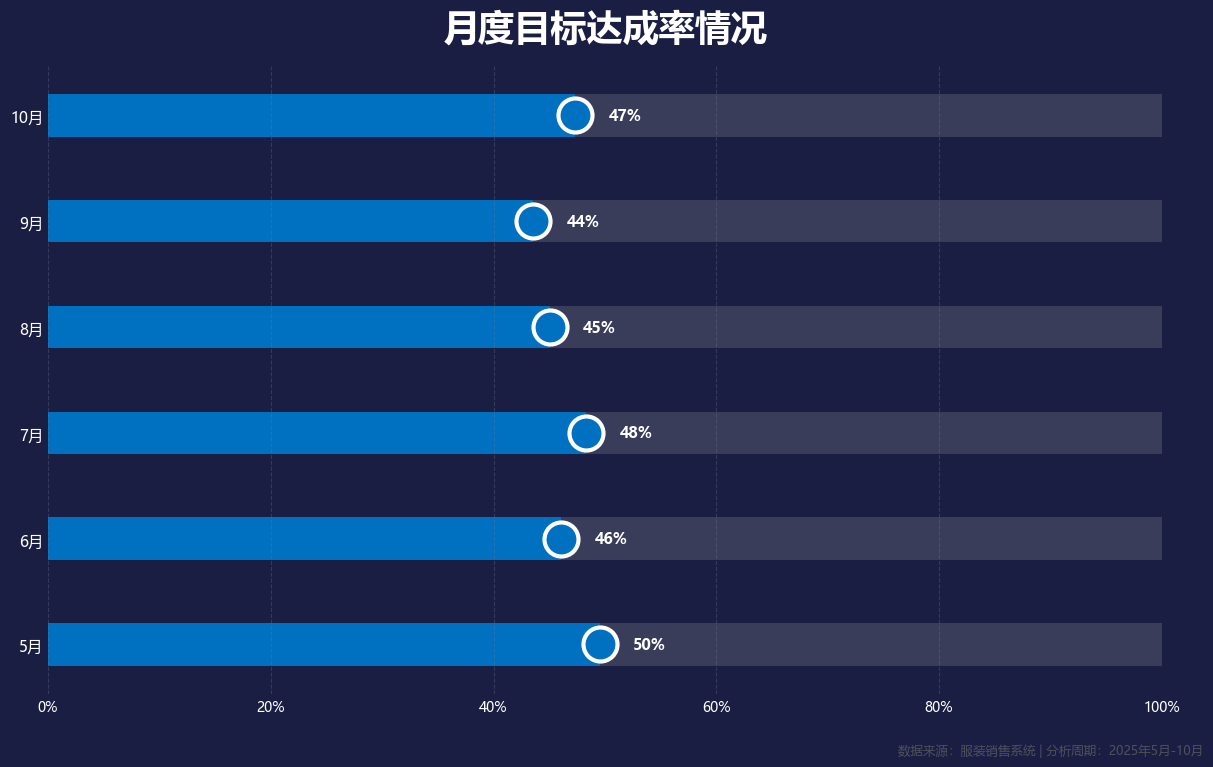

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

try:
    # 读取订单数据
    df = pd.read_csv("../../数据生成/erp_order.csv", encoding='utf-8-sig', parse_dates=["下单时间"])
    
    # 验证必要字段
    required_columns = ['下单时间', '状态']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    if df.empty:
        raise ValueError("订单数据为空")
    if df['状态'].isnull().all():
        raise ValueError("订单状态数据全部为空")
    
    # 数据预处理
    df["月份"] = df["下单时间"].dt.to_period("M").astype(str)
    
    # 月度订单完成率统计
    month_summary = (
        df.groupby("月份")["状态"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    status_columns = ["待付款", "已付款", "已发货", "已完成", "已取消"]
    for s in status_columns:
        if s not in month_summary.columns:
            month_summary[s] = 0
    month_summary["总订单数"] = month_summary[status_columns].sum(axis=1)
    month_summary["完成率"] = month_summary["已完成"] / month_summary["总订单数"]
    
    month_summary["月份_dt"] = pd.to_datetime(month_summary["月份"])
    month_summary = month_summary.sort_values("月份_dt")
    
    # 绘制滑珠图
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
    fig.patch.set_facecolor('#1A1E43')
    ax.set_facecolor('#1A1E43')

    # 隐藏边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Y轴类别
    y_labels = month_summary["月份"]
    y_pos = np.arange(len(y_labels))
    
    # 完成率数值
    rates = (month_summary["完成率"] * 100).to_numpy()

    # 绘制灰色底条
    ax.barh(y_pos, [100]*len(rates), color='#3a3d5a', height=0.4)

    # 绘制彩色完成条
    ax.barh(y_pos, rates, color='#0070c0', height=0.4)

    # 滑珠标记
    ax.scatter(rates, y_pos, s=600, color='#0070c0', edgecolors='white', linewidths=3, zorder=5)

    # 添加文字标注
    for i, rate in enumerate(rates):
        ax.text(rate + 3, y_pos[i], f"{rate:.0f}%", va='center', ha='left', color='white', fontsize=11, fontweight='bold')

    # 设置Y轴标签
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{int(pd.to_datetime(m).month)}月" for m in y_labels], color='white', fontsize=11)

    # 设置X轴样式
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=0)

    # 添加标题与来源
    plt.title("月度目标达成率情况", fontsize=26, fontweight="bold", color="white", pad=20)
    plt.figtext(
        0.88, 0,
        '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )

    # 添加网格线
    ax.grid(axis='x', linestyle='--', alpha=0.3, color='#777b92')
    ax.grid(axis='y', visible=False)

    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    plt.savefig("月度目标达成率情况.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **5月**：
  - 目标达成率为50%，表明该月的销售目标达到了一半，可能反映了市场需求的稳定性或销售策略的有效性。

- **6月**：
  - 目标达成率下降至46%，显示出该月的销售目标未完全实现，可能需要进一步分析原因。

- **7月**：
  - 目标达成率上升至48%，表明销售策略的调整或市场需求的增加可能促进了销售目标的实现。

- **8月**：
  - 目标达成率进一步下降至45%，可能指示了市场环境的变化或销售执行中的挑战。

- **9月**：
  - 目标达成率降至44%，为分析期间的最低点，需要深入探讨影响因素并制定改进措施。

- **10月**：
  - 目标达成率回升至47%，显示出销售业绩的改善迹象，可能与季节性因素或促销活动有关。


# 结论

从月度目标达成率分析来看，5月和7月的表现相对较好，而6月、8月和9月的达成率较低，这可能与市场需求波动、竞争环境变化或内部执行效率有关。10月的回升可能表明了策略调整或市场条件的改善。